# SentimentScope: Sentiment Analysis of Movie Reviews with a Transformer Built from Scratch

**Author:** Dennis O'Higgins

CineScope wants to understand how audiences feel about films. In this notebook I build, train and evaluate a small GPT-style transformer in PyTorch that classifies IMDB movie reviews as **negative (0)** or **positive (1)**.

## Outline
1. Setup and data loading
2. Data exploration and visualization
3. Dataset and DataLoader preparation
4. Model architecture (`DemoGPT`)
5. Training
6. Evaluation on the test set
7. Inference interface and checkpoint
8. Conclusion

## What is sentiment analysis?
Sentiment analysis is the task of determining the emotional tone of a piece of text. Here it is a binary classification problem: given the text of a review, predict whether the reviewer's opinion is positive or negative.

## The data
The Large Movie Review Dataset (Maas et al., 2011) contains 50,000 labelled IMDB reviews, split evenly into 25,000 training and 25,000 test reviews, each perfectly balanced between positive and negative sentiment.

In [1]:
import os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 1. Setup and data loading
The dataset is downloaded from Stanford University and extracted if it is not already present.

In [2]:
if not os.path.exists('aclImdb_v1.tar.gz'):
    !wget -q https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
if not os.path.isdir('aclImdb'):
    !tar -xzf aclImdb_v1.tar.gz
print(os.listdir('aclImdb'))

['train', 'imdb.vocab', 'README', 'test', 'imdbEr.txt']


In [3]:
train_pos_path = 'aclImdb/train/pos'
train_neg_path = 'aclImdb/train/neg'
test_pos_path = 'aclImdb/test/pos'
test_neg_path = 'aclImdb/test/neg'

def load_dataset(folder):
    """Read every .txt review in `folder` and return the review texts as a list."""
    reviews = []
    for filename in sorted(os.listdir(folder)):
        if not filename.endswith('.txt'):
            continue
        with open(os.path.join(folder, filename), 'r', encoding='utf-8') as f:
            reviews.append(f.read())
    return reviews

In [4]:
train_pos = load_dataset(train_pos_path)
train_neg = load_dataset(train_neg_path)
test_pos = load_dataset(test_pos_path)
test_neg = load_dataset(test_neg_path)

train_df = pd.DataFrame({'review': train_pos + train_neg,
                         'label': [1] * len(train_pos) + [0] * len(train_neg)})
test_df = pd.DataFrame({'review': test_pos + test_neg,
                        'label': [1] * len(test_pos) + [0] * len(test_neg)})

print(train_df.shape, test_df.shape)
train_df.head()

(25000, 2) (25000, 2)


,review,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


In [5]:
assert train_df.shape == (25000, 2), f"Unexpected train shape: {train_df.shape}"
assert test_df.shape == (25000, 2), f"Unexpected test shape: {test_df.shape}"
print("Dimension checks passed.")

Dimension checks passed.


## 2. Data exploration and visualization

In [6]:
explore_df = train_df.copy()
explore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [7]:
explore_df['word_count'] = explore_df['review'].str.split().str.len()
explore_df['char_count'] = explore_df['review'].str.len()
print(explore_df[['word_count', 'char_count']].describe().round(1))
print()
print("Label counts (0 = negative, 1 = positive):")
print(explore_df['label'].value_counts().sort_index())
print()
print("Mean word count by label:")
print(explore_df.groupby('label')['word_count'].mean().round(1))

       word_count  char_count
count     25000.0     25000.0
mean        233.8      1325.1
std         173.7      1003.1
min          10.0        52.0
25%         127.0       702.0
50%         174.0       979.0
75%         284.0      1614.0
max        2470.0     13704.0

Label counts (0 = negative, 1 = positive):
label
0    12500
1    12500
Name: count, dtype: int64

Mean word count by label:
label
0    230.9
1    236.7
Name: word_count, dtype: float64


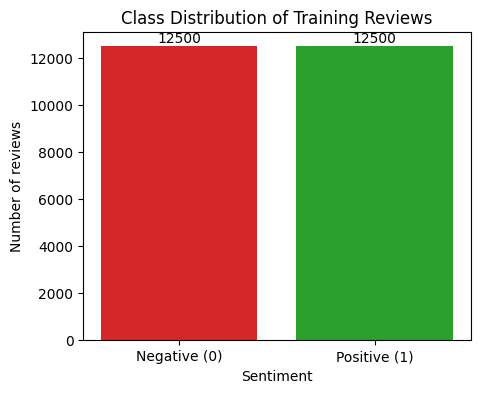

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = explore_df['label'].value_counts().sort_index()
ax.bar(['Negative (0)', 'Positive (1)'], counts.values, color=['tab:red', 'tab:green'])
ax.set_title('Class Distribution of Training Reviews')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of reviews')
for i, v in enumerate(counts.values):
    ax.text(i, v + 150, str(v), ha='center')
plt.show()

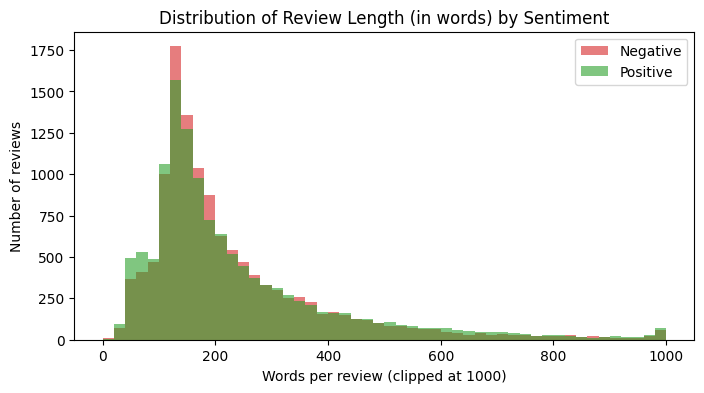

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1000, 51)
ax.hist(explore_df.loc[explore_df.label == 0, 'word_count'].clip(upper=1000), bins=bins,
        alpha=0.6, label='Negative', color='tab:red')
ax.hist(explore_df.loc[explore_df.label == 1, 'word_count'].clip(upper=1000), bins=bins,
        alpha=0.6, label='Positive', color='tab:green')
ax.set_title('Distribution of Review Length (in words) by Sentiment')
ax.set_xlabel('Words per review (clipped at 1000)')
ax.set_ylabel('Number of reviews')
ax.legend()
plt.show()

In [10]:
for label, name in [(0, 'NEGATIVE'), (1, 'POSITIVE')]:
    sample = explore_df[explore_df.label == label].sample(1, random_state=SEED)['review'].iloc[0]
    print(f"--- Sample {name} review ---")
    print(sample[:500] + ('...' if len(sample) > 500 else ''))
    print()

--- Sample NEGATIVE review ---
It's getting worse, the series is on a serious down fall. The first two sequel were acceptable and from then on we have seen a buch of really, really terrible movies. Robert Englund gives another great performance as Freddy but the rest of the cast can't act. The story is Alice, having survived the previous installment of the Nightmare series, finds the deadly dreams of Freddy Krueger starting once again. This time, the taunting murderer is striking through the sleeping mind of Alice's unborn ch...

--- Sample POSITIVE review ---
Oh, the sixties. There were some interesting films. I was more of a movie goer then. I now enjoy renting movies and relaxing in my home rather than going to the theater. I also saw this short film, " The Legend of the Boy and the Eagle". I have been searching for this film for years. It was truly inspiring. Surprisingly, I was finally able to gather more information from your site. Thank You........ I'm surprised to find out that

**Observations.** The training set is perfectly balanced (12,500 reviews per class), so accuracy is a fair metric and a trivial majority-class guess scores 50%. Reviews vary widely in length, with a long right tail, and positive and negative reviews have very similar length distributions. Because most reviews are longer than the model's context window, the model will see only the beginning of long reviews; the token-length analysis below quantifies this.

## 3. Dataset and DataLoader preparation

In [11]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
MAX_LENGTH = 128
BATCH_SIZE = 32
print("Vocabulary size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Vocabulary size: 30522


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (585 > 512). Running this sequence through the model will result in indexing errors


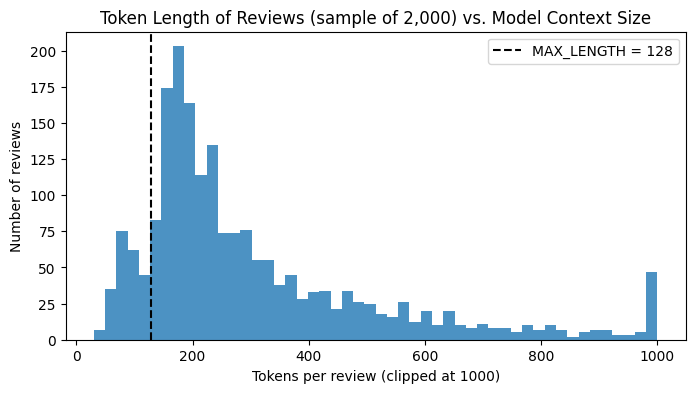

Share of reviews longer than 128 tokens: 88.5%


In [12]:
sample_tokens = explore_df['review'].sample(2000, random_state=SEED).apply(
    lambda t: len(tokenizer(t, add_special_tokens=True)['input_ids']))
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sample_tokens.clip(upper=1000), bins=50, color='tab:blue', alpha=0.8)
ax.axvline(MAX_LENGTH, color='black', linestyle='--', label=f'MAX_LENGTH = {MAX_LENGTH}')
ax.set_title('Token Length of Reviews (sample of 2,000) vs. Model Context Size')
ax.set_xlabel('Tokens per review (clipped at 1000)')
ax.set_ylabel('Number of reviews')
ax.legend()
plt.show()
print(f"Share of reviews longer than {MAX_LENGTH} tokens: {(sample_tokens > MAX_LENGTH).mean():.1%}")

In [13]:
train_data, val_data = train_test_split(train_df, test_size=0.1, shuffle=True, random_state=42)
train_data = train_data.reset_index(drop=True)
val_data = val_data.reset_index(drop=True)
print(len(train_data), len(val_data))
print("Positive share (train):", round(train_data.label.mean(), 3), "| (validation):", round(val_data.label.mean(), 3))

22500 2500
Positive share (train): 0.498 | (validation): 0.519


In [14]:
class IMDBDataset(Dataset):
    """Tokenizes IMDB reviews on the fly and returns (input_ids, label) pairs."""

    def __init__(self, data, tokenizer, max_length=MAX_LENGTH):
        self.data = data.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        review = self.data.loc[idx, 'review']
        label = int(self.data.loc[idx, 'label'])
        encoding = self.tokenizer(review,
                                  truncation=True,
                                  padding='max_length',
                                  max_length=self.max_length,
                                  return_tensors='pt')
        input_ids = encoding['input_ids'].squeeze(0)
        return input_ids, label

In [15]:
train_dataset = IMDBDataset(train_data, tokenizer)
val_dataset = IMDBDataset(val_data, tokenizer)
test_dataset = IMDBDataset(test_df, tokenizer)

assert len(train_dataset) == 22500, f"Train dataset length is {len(train_dataset)}"
assert len(val_dataset) == 2500, f"Validation dataset length is {len(val_dataset)}"
assert len(test_dataset) == 25000, f"Test dataset length is {len(test_dataset)}"

input_ids, label = train_dataset[0]
assert isinstance(input_ids, torch.Tensor), "input_ids must be a tensor"
assert isinstance(label, int), "label must be an int"
assert input_ids.shape[0] == train_dataset.max_length, "input_ids length must equal max_length"
print("Dataset checks passed. Example item:", input_ids.shape, label)

Dataset checks passed. Example item: torch.Size([128]) 1


In [16]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

batch_ids, batch_labels = next(iter(train_loader))
assert batch_ids.shape == (BATCH_SIZE, MAX_LENGTH)
assert batch_labels.shape == (BATCH_SIZE,)
print("Batch shapes:", batch_ids.shape, batch_labels.shape)

Batch shapes: torch.Size([32, 128]) torch.Size([32])


## 4. Model architecture
The model is a small decoder-style transformer (token embeddings, learned positional embeddings, stacked blocks of multi-head self-attention and feed-forward layers with residual connections and layer normalization). For classification, the sequence of hidden states is **mean-pooled** across the token dimension and passed through a linear layer that outputs two logits.

In [17]:
config = {
    "vocabulary_size": tokenizer.vocab_size,
    "num_classes": 2,
    "d_embed": 128,
    "context_size": MAX_LENGTH,
    "layers_num": 4,
    "heads_num": 4,
    "head_size": 32,
    "dropout_rate": 0.1,
    "use_bias": True,
}

class AttentionHead(nn.Module):
    """A single causal self-attention head."""
    def __init__(self, config):
        super().__init__()
        self.Q_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.K_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.V_weights = nn.Linear(config["d_embed"], config["head_size"], bias=config["use_bias"])
        self.dropout = nn.Dropout(config["dropout_rate"])
        casual_attention_mask = torch.tril(torch.ones(config["context_size"], config["context_size"]))
        self.register_buffer('casual_attention_mask', casual_attention_mask)

    def forward(self, input):
        batch_size, tokens_num, d_embed = input.shape
        Q = self.Q_weights(input)
        K = self.K_weights(input)
        V = self.V_weights(input)
        attention_scores = Q @ K.transpose(1, 2)
        attention_scores = attention_scores.masked_fill(
            self.casual_attention_mask[:tokens_num, :tokens_num] == 0, float('-inf'))
        attention_scores = attention_scores / (K.shape[-1] ** 0.5)
        attention_scores = torch.softmax(attention_scores, dim=-1)
        attention_scores = self.dropout(attention_scores)
        return attention_scores @ V

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        heads_list = [AttentionHead(config) for _ in range(config["heads_num"])]
        self.heads = nn.ModuleList(heads_list)
        self.linear = nn.Linear(config["heads_num"] * config["head_size"], config["d_embed"])
        self.dropout = nn.Dropout(config["dropout_rate"])

    def forward(self, input):
        heads_outputs = [head(input) for head in self.heads]
        x = torch.cat(heads_outputs, dim=-1)
        x = self.linear(x)
        return self.dropout(x)

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(config["d_embed"], 4 * config["d_embed"]),
            nn.GELU(),
            nn.Linear(4 * config["d_embed"], config["d_embed"]),
            nn.Dropout(config["dropout_rate"]),
        )

    def forward(self, input):
        return self.linear_layers(input)

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.multi_head = MultiHeadAttention(config)
        self.layer_norm_1 = nn.LayerNorm(config["d_embed"])
        self.feed_forward = FeedForward(config)
        self.layer_norm_2 = nn.LayerNorm(config["d_embed"])

    def forward(self, input):
        residual = input
        x = self.multi_head(self.layer_norm_1(input))
        x = x + residual
        residual = x
        x = self.feed_forward(self.layer_norm_2(x))
        return x + residual

In [18]:
class DemoGPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.token_embedding_layer = nn.Embedding(config["vocabulary_size"], config["d_embed"])
        self.positional_embedding_layer = nn.Embedding(config["context_size"], config["d_embed"])
        blocks = [Block(config) for _ in range(config["layers_num"])]
        self.layers = nn.Sequential(*blocks)
        self.layer_norm = nn.LayerNorm(config["d_embed"])
        # Classification head: maps the pooled representation to class logits.
        self.classifier = nn.Linear(config["d_embed"], config["num_classes"], bias=False)

    def forward(self, token_ids):
        batch_size, tokens_num = token_ids.shape
        x = self.token_embedding_layer(token_ids)
        positions = torch.arange(tokens_num, device=token_ids.device)
        x = x + self.positional_embedding_layer(positions)
        x = self.layers(x)
        x = self.layer_norm(x)
        x = torch.mean(x, dim=1)          # mean pooling over the sequence
        logits = self.classifier(x)       # shape: (batch_size, num_classes)
        return logits

    @torch.no_grad()
    def predict_proba(self, token_ids):
        """Class probabilities (softmax over the logits)."""
        return F.softmax(self.forward(token_ids), dim=-1)

In [19]:
model = DemoGPT(config).to(device)
with torch.no_grad():
    test_logits = model(batch_ids.to(device))
assert test_logits.shape == (BATCH_SIZE, config["num_classes"]), f"Unexpected output shape {test_logits.shape}"
n_params = sum(p.numel() for p in model.parameters())
print(f"Output shape: {tuple(test_logits.shape)} | Trainable parameters: {n_params:,}")

Output shape: (32, 2) | Trainable parameters: 4,716,800


## 5. Training
First, the accuracy helper used for validation and testing.

In [20]:
def calculate_accuracy(model, data_loader, device):
    """Return the classification accuracy (in percent) of `model` on `data_loader`."""
    model.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for input_ids, labels in data_loader:
            input_ids = input_ids.to(device)
            labels = labels.to(device)
            logits = model(input_ids)
            predictions = torch.argmax(logits, dim=1)
            total_correct += (predictions == labels).sum().item()
            total_samples += labels.size(0)
    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [21]:
EPOCHS = 8
LEARNING_RATE = 3e-4
CHECKPOINT_PATH = 'sentimentscope_checkpoint.pt'

model = DemoGPT(config).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

history = {"train_loss": [], "val_accuracy": []}
best_val_accuracy = 0.0
best_epoch = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    epoch_loss = 0.0
    start = time.time()
    for step, (input_ids, labels) in enumerate(train_loader, start=1):
        input_ids = input_ids.to(device)
        labels = labels.to(device)

        logits = model(input_ids)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        epoch_loss += loss.item()
        if step % 100 == 0:
            print(f"Epoch {epoch + 1}/{EPOCHS} | Step {step}/{len(train_loader)} | Loss: {running_loss / 100:.4f}")
            running_loss = 0.0

    avg_loss = epoch_loss / len(train_loader)
    val_accuracy = calculate_accuracy(model, val_loader, device)
    history["train_loss"].append(avg_loss)
    history["val_accuracy"].append(val_accuracy)
    print(f"==> Epoch {epoch + 1} done in {time.time() - start:.0f}s | Train loss: {avg_loss:.4f} | Validation accuracy: {val_accuracy:.2f}%")

    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        best_epoch = epoch + 1
        torch.save({"model_state_dict": model.state_dict(),
                    "config": config,
                    "max_length": MAX_LENGTH,
                    "tokenizer_name": "bert-base-uncased",
                    "epoch": best_epoch,
                    "val_accuracy": best_val_accuracy}, CHECKPOINT_PATH)

print(f"Best validation accuracy: {best_val_accuracy:.2f}% (epoch {best_epoch}). Checkpoint saved to {CHECKPOINT_PATH}")

Epoch 1/8 | Step 100/704 | Loss: 0.6921
Epoch 1/8 | Step 200/704 | Loss: 0.6588
Epoch 1/8 | Step 300/704 | Loss: 0.6432
Epoch 1/8 | Step 400/704 | Loss: 0.6135
Epoch 1/8 | Step 500/704 | Loss: 0.5967
Epoch 1/8 | Step 600/704 | Loss: 0.5907
Epoch 1/8 | Step 700/704 | Loss: 0.5692
==> Epoch 1 done in 50s | Train loss: 0.6236 | Validation accuracy: 67.24%
Epoch 2/8 | Step 100/704 | Loss: 0.5311
Epoch 2/8 | Step 200/704 | Loss: 0.5409
Epoch 2/8 | Step 300/704 | Loss: 0.5145
Epoch 2/8 | Step 400/704 | Loss: 0.5069
Epoch 2/8 | Step 500/704 | Loss: 0.5070
Epoch 2/8 | Step 600/704 | Loss: 0.5025
Epoch 2/8 | Step 700/704 | Loss: 0.4766
==> Epoch 2 done in 56s | Train loss: 0.5112 | Validation accuracy: 75.84%
Epoch 3/8 | Step 100/704 | Loss: 0.4427
Epoch 3/8 | Step 200/704 | Loss: 0.4298
Epoch 3/8 | Step 300/704 | Loss: 0.4488
Epoch 3/8 | Step 400/704 | Loss: 0.4397
Epoch 3/8 | Step 500/704 | Loss: 0.4434
Epoch 3/8 | Step 600/704 | Loss: 0.4356
Epoch 3/8 | Step 700/704 | Loss: 0.4301
==> Epoch 

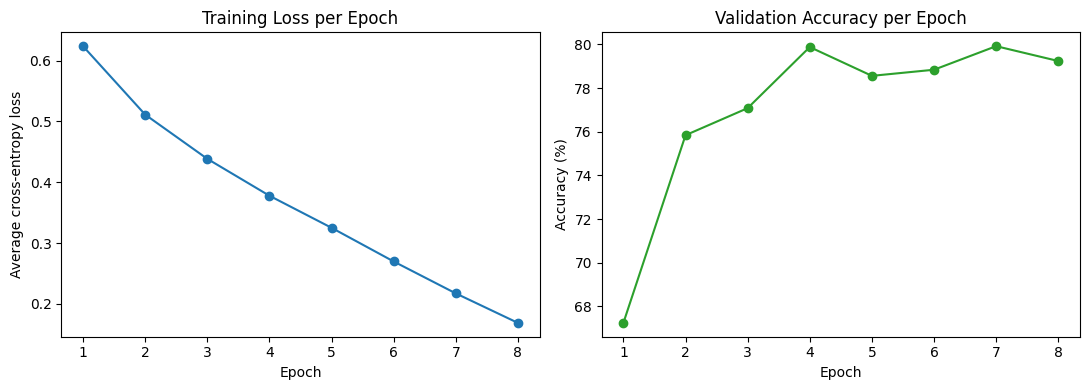

In [22]:
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs_range, history["train_loss"], marker='o', color='tab:blue')
axes[0].set_title('Training Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Average cross-entropy loss')
axes[1].plot(epochs_range, history["val_accuracy"], marker='o', color='tab:green')
axes[1].set_title('Validation Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

## 6. Evaluation on the test set
The best checkpoint (selected by validation accuracy, never by test accuracy) is reloaded and evaluated once on the 25,000 held-out test reviews.

In [23]:
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model = DemoGPT(checkpoint["config"]).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

test_accuracy = calculate_accuracy(model, test_loader, device)
print(f"Test accuracy: {test_accuracy:.2f}%")
assert test_accuracy > 75, f"Test accuracy {test_accuracy:.2f}% is below the 75% requirement"
print("Requirement met: test accuracy is above 75%.")

Test accuracy: 77.28%
Requirement met: test accuracy is above 75%.


## 7. Inference interface and checkpoint
`SentimentPredictor` loads the saved checkpoint and returns a label and class probabilities for any list of review texts.

In [24]:
class SentimentPredictor:
    """Simple inference interface around a saved SentimentScope checkpoint."""
    LABELS = {0: "negative", 1: "positive"}

    def __init__(self, checkpoint_path, device=None):
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        ckpt = torch.load(checkpoint_path, map_location=self.device)
        self.max_length = ckpt["max_length"]
        self.tokenizer = AutoTokenizer.from_pretrained(ckpt["tokenizer_name"])
        self.model = DemoGPT(ckpt["config"]).to(self.device)
        self.model.load_state_dict(ckpt["model_state_dict"])
        self.model.eval()

    def predict(self, texts):
        if isinstance(texts, str):
            texts = [texts]
        enc = self.tokenizer(texts, truncation=True, padding="max_length",
                             max_length=self.max_length, return_tensors="pt")
        probs = self.model.predict_proba(enc["input_ids"].to(self.device)).cpu()
        results = []
        for text, p in zip(texts, probs):
            idx = int(torch.argmax(p))
            results.append({"text": text, "sentiment": self.LABELS[idx],
                            "confidence": float(p[idx]),
                            "probabilities": {"negative": float(p[0]), "positive": float(p[1])}})
        return results

predictor = SentimentPredictor(CHECKPOINT_PATH, device)
examples = [
    "This movie was absolutely fantastic! The acting was superb and the story kept me engaged the whole time.",
    "A dull, predictable mess. I wanted my two hours back.",
    "The cinematography was beautiful, but the plot dragged and the ending felt rushed.",
]
for r in predictor.predict(examples):
    print(f"{r['sentiment'].upper():8s} ({r['confidence']:.1%}) | {r['text']}")

POSITIVE (99.9%) | This movie was absolutely fantastic! The acting was superb and the story kept me engaged the whole time.
NEGATIVE (97.6%) | A dull, predictable mess. I wanted my two hours back.
POSITIVE (63.3%) | The cinematography was beautiful, but the plot dragged and the ending felt rushed.


In [25]:
# Confirm the reloaded checkpoint reproduces the reported test accuracy through the predictor's model.
reloaded_accuracy = calculate_accuracy(predictor.model, test_loader, device)
print(f"Test accuracy from reloaded checkpoint: {reloaded_accuracy:.2f}%")
print(f"Checkpoint file size: {os.path.getsize(CHECKPOINT_PATH) / 1e6:.1f} MB")

Test accuracy from reloaded checkpoint: 77.28%
Checkpoint file size: 20.0 MB


## 8. Conclusion

In [26]:
from IPython.display import Markdown, display
display(Markdown(f"""
### Results summary
I trained a {n_params:,}-parameter transformer ({config['layers_num']} layers, {config['heads_num']} heads, embedding size {config['d_embed']}) from scratch on 22,500 IMDB reviews for {EPOCHS} epochs. The best epoch by validation accuracy was epoch {best_epoch} with **{best_val_accuracy:.2f}%** validation accuracy. On the 25,000 held-out test reviews the saved checkpoint achieves **{test_accuracy:.2f}%** accuracy, which exceeds the 75% requirement. The checkpoint is saved as `{CHECKPOINT_PATH}` and can be used through the `SentimentPredictor` class above.

### Key takeaways
1. **A small transformer trained from scratch can learn sentiment reasonably well.** Without any pretrained weights and with a context of only {MAX_LENGTH} tokens, the model reaches {test_accuracy:.1f}% test accuracy, far above the 50% chance level of this balanced dataset.
2. **Validation-based checkpointing guards against overfitting.** Training loss kept falling while validation accuracy plateaued (see the curves in Section 5), so selecting the checkpoint on the validation split rather than the final epoch gives a more trustworthy test result.
3. **Truncation limits performance.** Most reviews are longer than {MAX_LENGTH} tokens, so the model sees only the opening of many reviews. A longer context, a pretrained model, or a chunking strategy would likely improve accuracy further, at a higher computational cost.
"""))


### Results summary
I trained a 4,716,800-parameter transformer (4 layers, 4 heads, embedding size 128) from scratch on 22,500 IMDB reviews for 8 epochs. The best epoch by validation accuracy was epoch 7 with **79.92%** validation accuracy. On the 25,000 held-out test reviews the saved checkpoint achieves **77.28%** accuracy, which exceeds the 75% requirement. The checkpoint is saved as `sentimentscope_checkpoint.pt` and can be used through the `SentimentPredictor` class above.

### Key takeaways
1. **A small transformer trained from scratch can learn sentiment reasonably well.** Without any pretrained weights and with a context of only 128 tokens, the model reaches 77.3% test accuracy, far above the 50% chance level of this balanced dataset.
2. **Validation-based checkpointing guards against overfitting.** Training loss kept falling while validation accuracy plateaued (see the curves in Section 5), so selecting the checkpoint on the validation split rather than the final epoch gives a more trustworthy test result.
3. **Truncation limits performance.** Most reviews are longer than 128 tokens, so the model sees only the opening of many reviews. A longer context, a pretrained model, or a chunking strategy would likely improve accuracy further, at a higher computational cost.
